                                  BT 401
                             NAME : BANOTH KRISHNA
                             ROLLNO: 220106019
                            UNDER THE SUPERVISION OF
                             Prof.Himanshu singh.
                Department of Biosciences and Bioengineering
                  INDIAN INSTITUTE OF TECHNOLOGY, Guwahati.
                                 
ABSTRACT:

In this work, I developed a Python-based computational framework to analyze and visualize NMR relaxation data that were originally processed using Mathematica.

This transition from Mathematica to Python significantly improved the reproducibility, scalability, and automation of NMR relaxation data analysis.

Python-readable formats and automated the data extraction, cleaning, sorting, and visualization processes using libraries such as pandas, NumPy, and Matplotlib.

The datasets containing residue-wise ¹⁵N R₁ρ relaxation rates were converted, visualized, and validated using Python, enhancing accuracy, reproducibility, and computational efficiency in protein dynamics analysis.

In NMR spectroscopy, R₁ρ relaxation measurements are used to probe microsecond-to-millisecond timescale motions in proteins.
The relaxation rate constant
gives information about conformational exchange, flexibility, and local structural dynamics.

Low R₁ρ values (e.g., ~4–6 s⁻¹): indicate rigid, well-structured regions of the protein.

High R₁ρ values (e.g., ~20–30 s⁻¹): indicate flexible, dynamic regions experiencing conformational exchange.

The plot illustrates the variation of R₁ρ relaxation rates across protein residues. Peaks represent flexible or conformationally dynamic regions, while troughs correspond to rigid, structured segments. The pattern highlights residue-specific internal motions, providing insights into the protein’s backbone dynamics and potential sites of conformational exchange.

Across all datasets, the statistical parameters such as mean, median, standard deviation, and range describe the overall distribution and variability of R₁ρ relaxation rates among protein residues.

The mean relaxation rate represents the average dynamic behavior of residues, indicating the general level of internal motion within the protein backbone.

The median (50th percentile) provides a robust measure of the central tendency, showing the typical relaxation rate unaffected by extreme values.

The standard deviation reflects how widely the relaxation rates vary across residues — a larger value indicates greater dynamic heterogeneity.

The minimum and maximum values define the range of molecular motions, from highly rigid (low R₁ρ) to flexible or exchanging regions (high R₁ρ).

Together, these statistics summarize the overall conformational flexibility and stability patterns observed in all the datasets, highlighting regions of structural order and dynamic motion within the protein.



R1rho_ls_15N_on_1

1 kHz Statistics:
count    213.000000
mean      11.441142
std        5.628070
min        3.681827
25%        7.058824
50%        9.521540
75%       15.198738
max       32.662241
Name: R1rho_value, dtype: float64


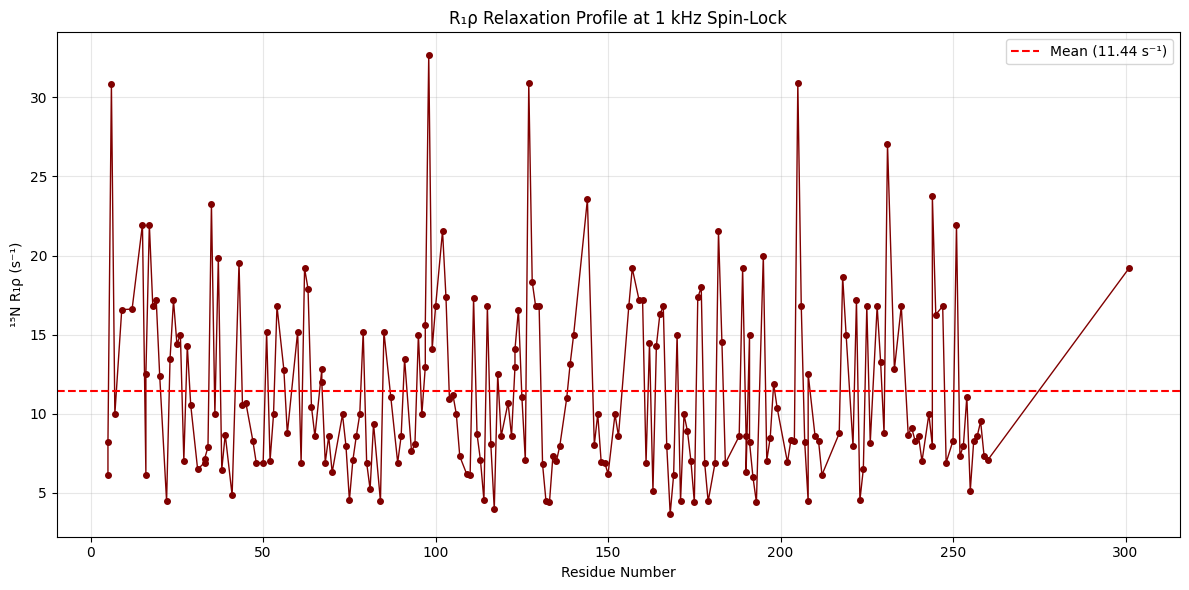


Data saved to 'r1rho_1kHz_data.csv'


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_1k = 'R1rho_ls_15N_on_1kexpfunfitresults.txt'


df_1 = parse_r1rho_file(file_1k, '1 kHz')

# Summary statistics
print("1 kHz Statistics:")
print(df_1['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_1.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='maroon')
plt.axhline(y=df_1['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_1["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 1 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_1kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_1.to_csv('r1rho_1kHz_data.csv', index=False)
print("\nData saved to 'r1rho_1kHz_data.csv'")

R1rho_ls_15N_on_1.5

1.5 kHz Statistics:
count    213.000000
mean       9.390180
std        4.602117
min        0.044678
25%        6.347972
50%        8.320150
75%       11.456042
max       28.889210
Name: R1rho_value, dtype: float64


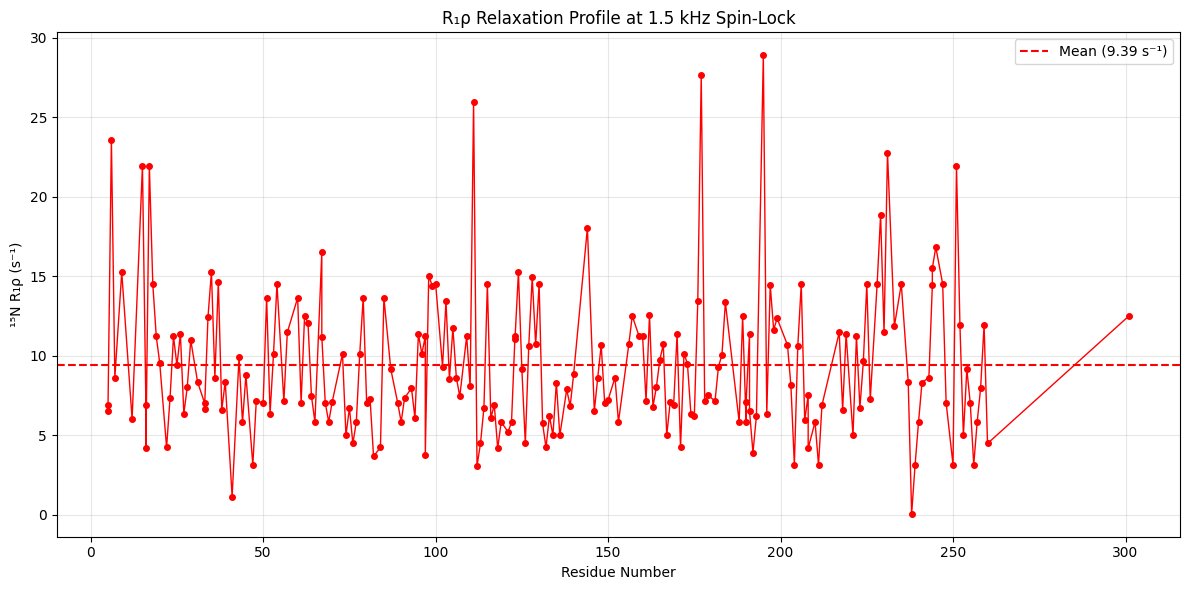


Data saved to 'r1rho_1.5kHz_data.csv'


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_1_5k = 'R1rho_ls_15N_on_1.5kexpfunfitresults.txt'

# Parse file
df_1_5 = parse_r1rho_file(file_1_5k, '1.5 kHz')

# Summary statistics
print("1.5 kHz Statistics:")
print(df_1_5['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_1_5.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='red')
plt.axhline(y=df_1_5['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_1_5["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 1.5 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_1.5kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_1_5.to_csv('r1rho_1.5kHz_data.csv', index=False)
print("\nData saved to 'r1rho_1.5kHz_data.csv'")

R1rho_ls_15N_on_2.5

2.5 kHz Statistics:
count    213.000000
mean       7.336814
std        5.251275
min        2.768112
25%        4.722335
50%        5.969302
75%        8.439642
max       63.816580
Name: R1rho_value, dtype: float64


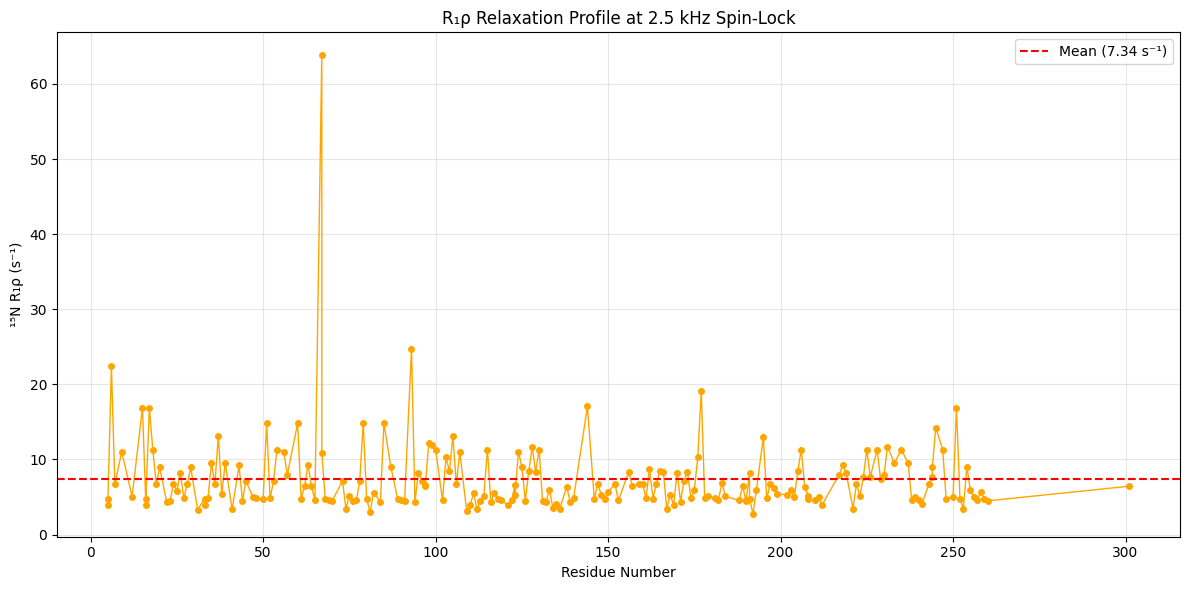


Data saved to 'r1rho_2.5kHz_data.csv'


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_2_5k = 'R1rho_ls_15N_on_2.5kexpfunfitresults.txt'

# Parse file
df_2_5 = parse_r1rho_file(file_2_5k, '2.5 kHz')

# Summary statistics
print("2.5 kHz Statistics:")
print(df_2_5['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_2_5.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='orange')
plt.axhline(y=df_2_5['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_2_5["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 2.5 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_2.5kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_2_5.to_csv('r1rho_2.5kHz_data.csv', index=False)
print("\nData saved to 'r1rho_2.5kHz_data.csv'")

R1rho_ls_15N_on_2

2 kHz Statistics:
count    213.000000
mean       7.708307
std        4.170191
min        2.701597
25%        4.956436
50%        6.499801
75%        9.196865
max       23.743371
Name: R1rho_value, dtype: float64


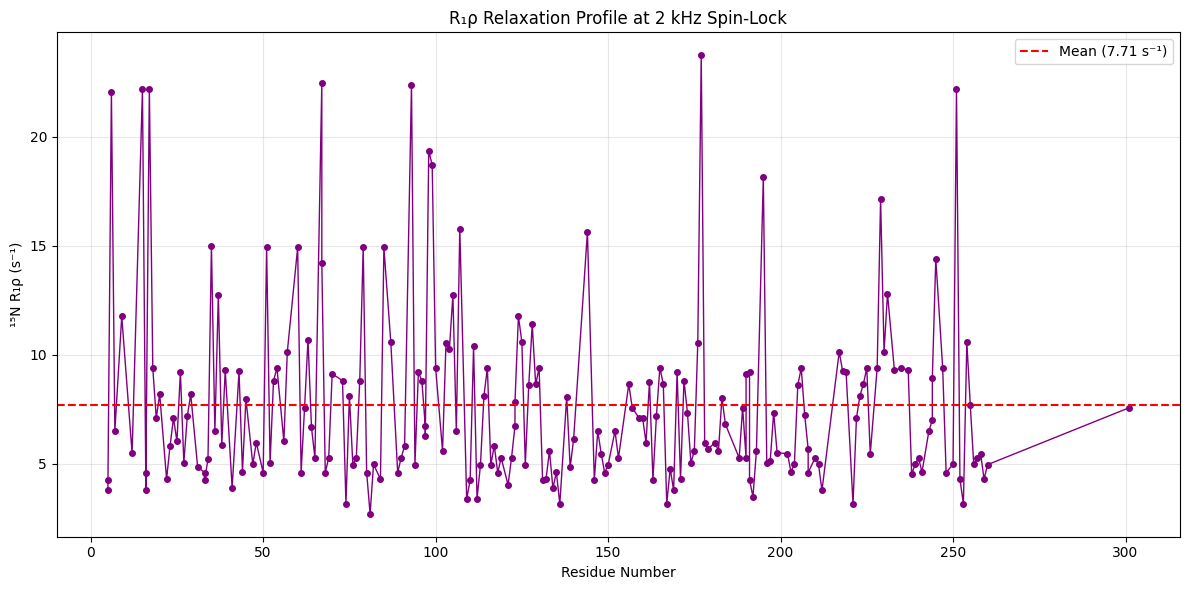


Data saved to 'r1rho_2kHz_data.csv'


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_2k = 'R1rho_ls_15N_on_2kexpfunfitresults.txt'

# Parse file
df_2 = parse_r1rho_file(file_2k, '2 kHz')

# Summary statistics
print("2 kHz Statistics:")
print(df_2['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_2.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='purple')
plt.axhline(y=df_2['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_2["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 2 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_2kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_2.to_csv('r1rho_2kHz_data.csv', index=False)
print("\nData saved to 'r1rho_2kHz_data.csv'")

R1rho_ls_15N_on_3

3 kHz Statistics:
count    213.000000
mean       6.627959
std        3.461884
min        2.526811
25%        4.204007
50%        5.334100
75%        7.602492
max       24.381688
Name: R1rho_value, dtype: float64


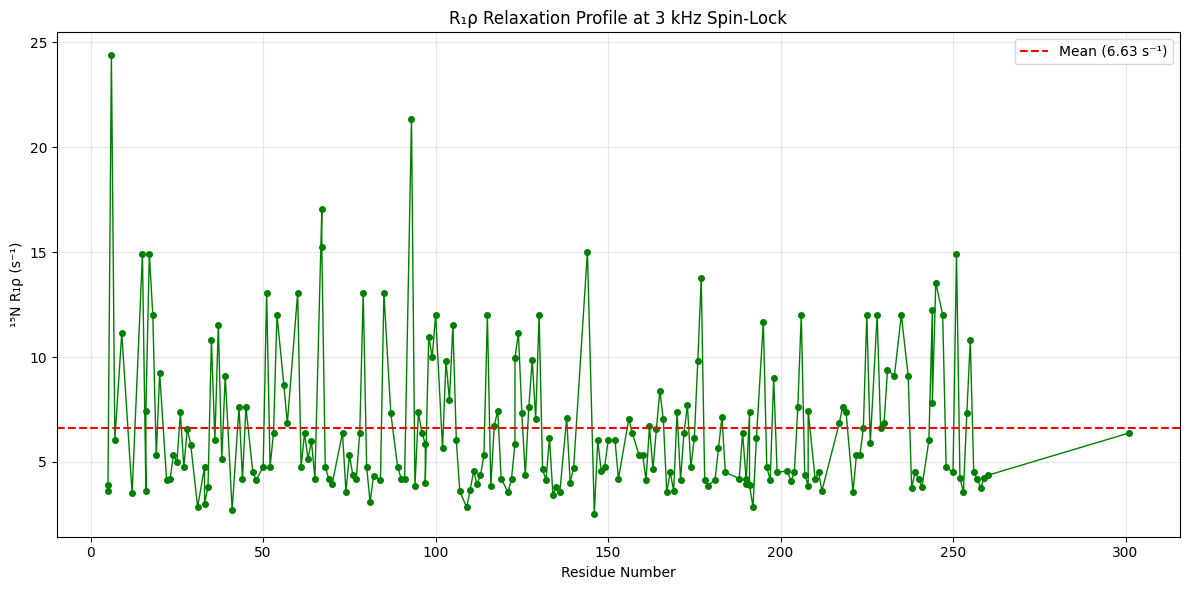


Data saved to 'r1rho_3kHz_data.csv'


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_3k = 'R1rho_ls_15N_on_3kexpfunfitresults.txt'

# Parse file
df_3 = parse_r1rho_file(file_3k, '3 kHz')

# Summary statistics
print("3 kHz Statistics:")
print(df_3['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_3.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='green')
plt.axhline(y=df_3['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_3["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 3 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_3kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_3.to_csv('r1rho_3kHz_data.csv', index=False)
print("\nData saved to 'r1rho_3kHz_data.csv'")

R1rho_ls_15N_on_4

4 kHz Statistics:
count    213.000000
mean       6.074201
std        3.085447
min        2.033295
25%        4.146871
50%        4.712059
75%        7.048262
max       22.519805
Name: R1rho_value, dtype: float64


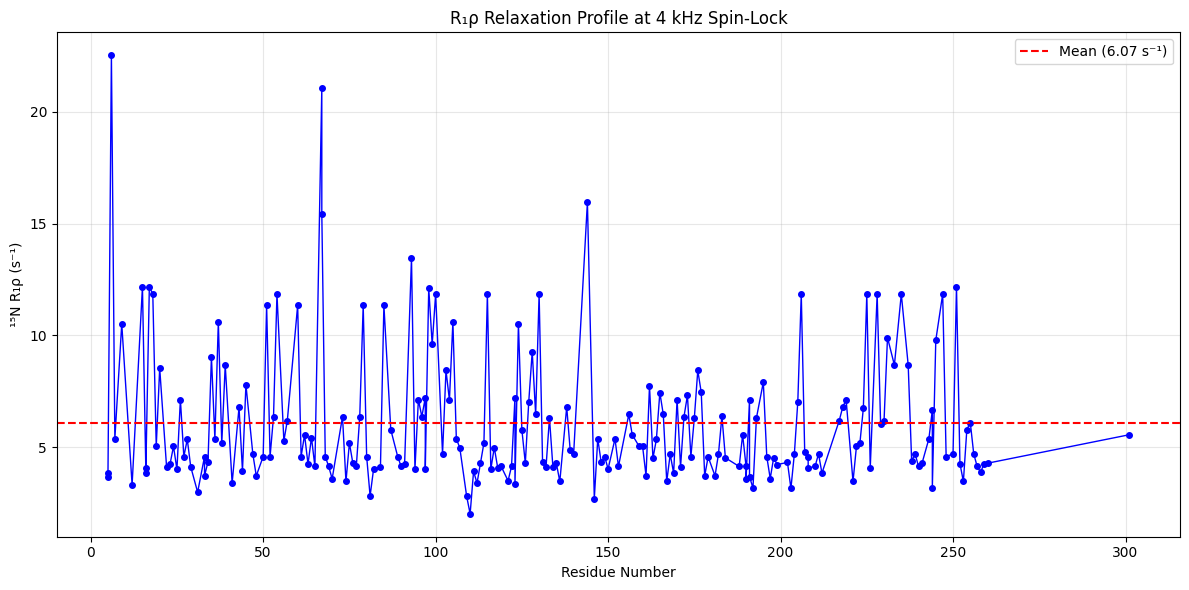


Data saved to 'r1rho_4kHz_data.csv'


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_4k = 'R1rho_ls_15N_on_4kexpfunfitresults.txt'

# Parse file
df_4 = parse_r1rho_file(file_4k, '4 kHz')

# Summary statistics
print("4 kHz Statistics:")
print(df_4['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_4.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='blue')
plt.axhline(y=df_4['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_4["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 4 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_4kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_4.to_csv('r1rho_4kHz_data.csv', index=False)
print("\nData saved to 'r1rho_4kHz_data.csv'")

R1rho_ls_15N_on_5

5 kHz Statistics:
count    213.000000
mean       5.458030
std        2.229344
min        2.638887
25%        4.045007
50%        4.634678
75%        6.440097
max       16.390039
Name: R1rho_value, dtype: float64


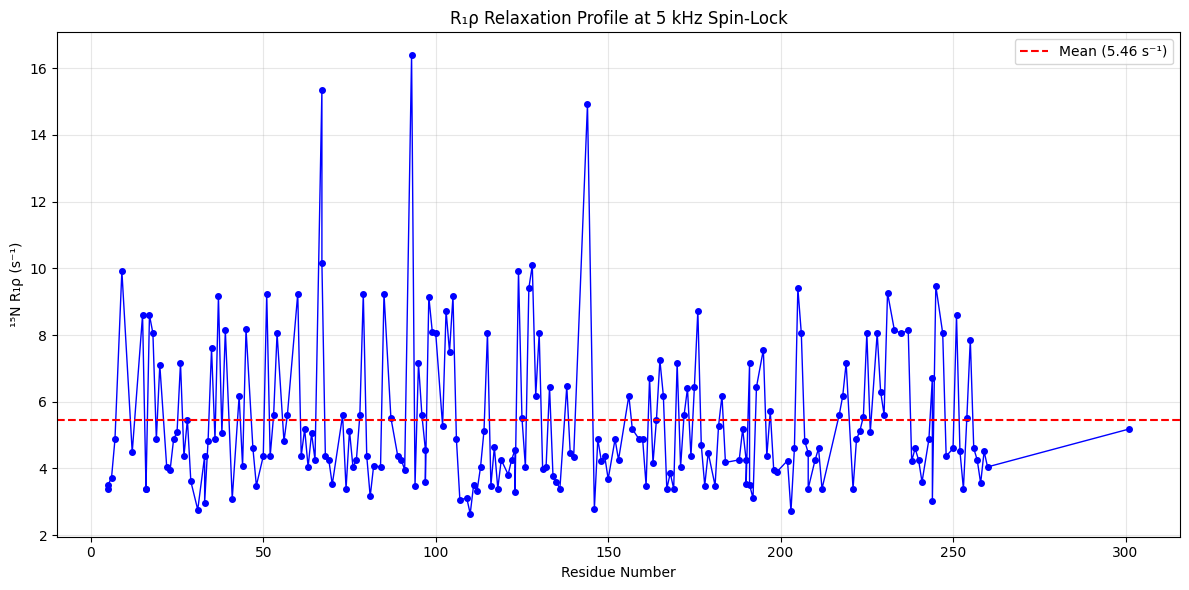


Data saved to 'r1rho_5kHz_data.csv'


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_5k = 'R1rho_ls_15N_on_5kexpfunfitresults.txt'

# Parse file
df_5 = parse_r1rho_file(file_5k, '5 kHz')

# Summary statistics
print("5 kHz Statistics:")
print(df_5['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_5.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='blue')
plt.axhline(y=df_5['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_5["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 5 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_5kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_5.to_csv('r1rho_5kHz_data.csv', index=False)
print("\nData saved to 'r1rho_5kHz_data.csv'")

R1rho_ls_15N_on_7

7 kHz Statistics:
count    213.000000
mean       5.044786
std        2.163424
min        1.963759
25%        3.632431
50%        4.485776
75%        5.589895
max       16.336089
Name: R1rho_value, dtype: float64


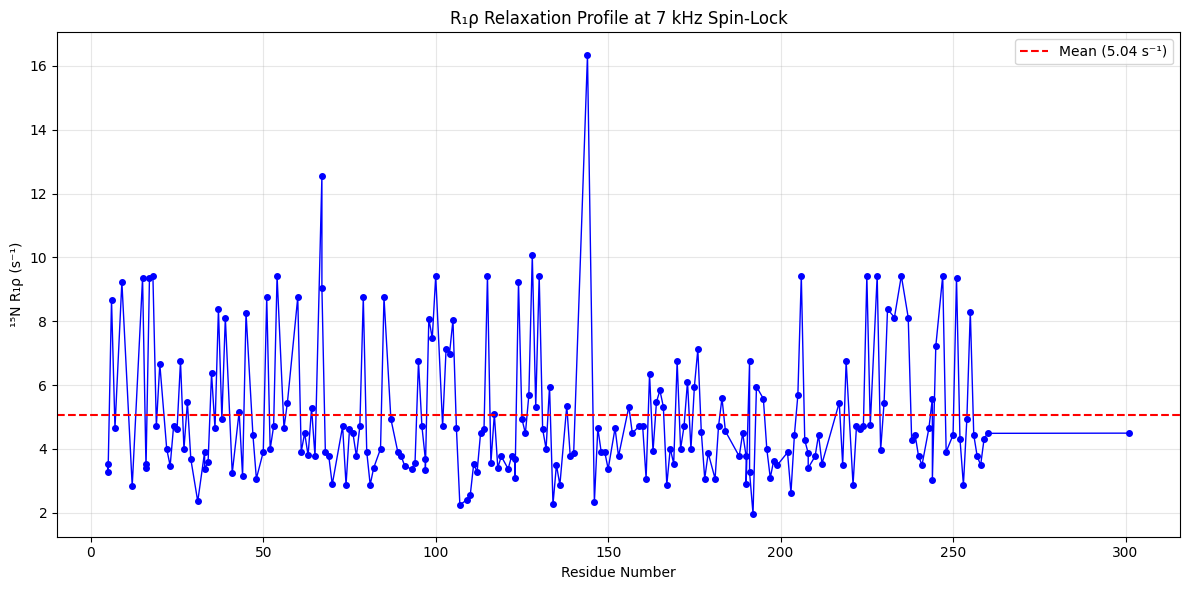


Data saved to 'r1rho_7kHz_data.csv'


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_7k = 'R1rho_ls_15N_on_7kexpfunfitresults.txt'

# Parse file
df_7 = parse_r1rho_file(file_7k, '7 kHz')

# Summary statistics
print("7 kHz Statistics:")
print(df_7['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_7.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='blue')
plt.axhline(y=df_7['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_7["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 7 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_7kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_7.to_csv('r1rho_7kHz_data.csv', index=False)
print("\nData saved to 'r1rho_7kHz_data.csv'")

R1rho_ls_15N_on_10


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    return df.dropna(subset=['res_num'])  # Drop any without residue number

# File path
file_10k = 'R1rho_ls_15N_on_10kexpfunfitresults.txt'

# Parse file
df_10 = parse_r1rho_file(file_10k, '10 kHz')

# Summary statistics
print("10 kHz Statistics:")
print(df_10['R1rho_value'].describe())

# Plot R1rho profile
plt.figure(figsize=(12, 6))
subset = df_10.sort_values('res_num')
plt.plot(subset['res_num'], subset['R1rho_value'], 'o-', linewidth=1, markersize=4, color='blue')
plt.axhline(y=df_10['R1rho_value'].mean(), color='r', linestyle='--', label=f'Mean ({df_10["R1rho_value"].mean():.2f} s⁻¹)')
plt.xlabel('Residue Number')
plt.ylabel('¹⁵N R₁ρ (s⁻¹)')
plt.title('R₁ρ Relaxation Profile at 10 kHz Spin-Lock')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r1rho_10kHz.png', dpi=300, bbox_inches='tight')
plt.show()

# Save cleaned data
df_10.to_csv('r1rho_10kHz_data.csv', index=False)
print("\nData saved to 'r1rho_10kHz_data.csv'")

10 kHz Statistics:
count    213.000000
mean       4.791068
std        1.821315
min        2.134475
25%        3.580290
50%        4.317956
75%        5.737452
max       16.738132
Name: R1rho_value, dtype: float64


r1rhoonresonance_withweightfactor

1k: 206 backbone points parsed
1.5k: 206 backbone points parsed
2k: 206 backbone points parsed
2.5k: 206 backbone points parsed
3k: 206 backbone points parsed

Common residues across all fields: 203

Summary statistics per field (backbone only):

1k:
count    296.000000
mean      10.636860
std        5.028431
min        3.681827
25%        6.914327
50%        8.586758
75%       12.805306
max       32.662241
Name: R1rho_1k, dtype: float64

1.5k:
count    296.000000
mean       9.329382
std        4.364910
min        0.044678
25%        6.611960
50%        7.381177
75%       11.250899
max       28.889210
Name: R1rho_1.5k, dtype: float64

2k:
count    296.000000
mean       8.444887
std        5.148087
min        2.701597
25%        4.921316
50%        6.499801
75%        9.385986
max       23.743371
Name: R1rho_2k, dtype: float64

2.5k:
count    296.000000
mean       9.828271
std       13.343226
min        2.768112
25%        4.540304
50%        5.151998
75%        9.092587
max       63.81

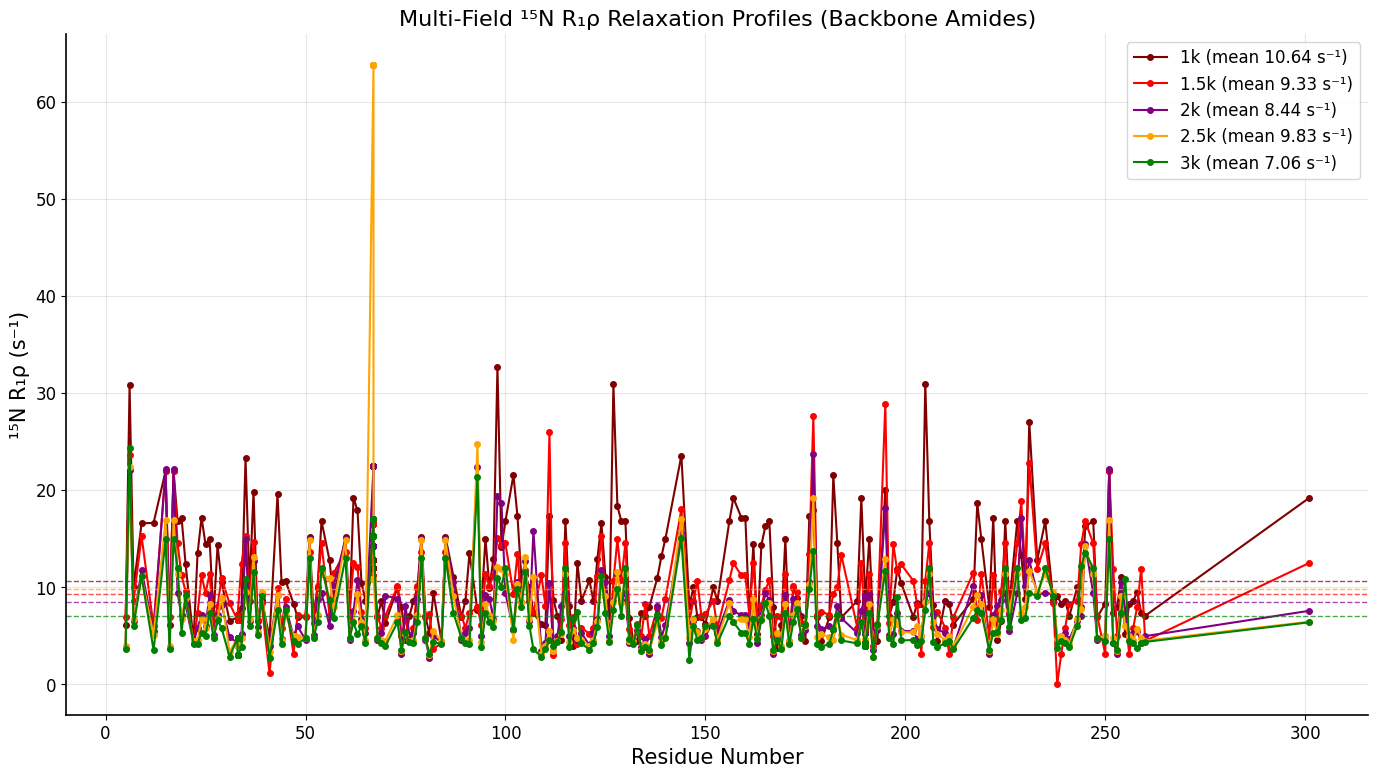


Merged data saved to 'merged_r1rho_backbone.csv'
Overlay plot saved to 'multi_field_r1rho_overlay.png'

Sample R_ex approximation (R1rho_1k - R1rho_3k):
     res_num  R_ex_approx
252    205.0    23.337207
159    127.0    23.337207
133     98.0    21.690023
271    231.0    17.670814
204    182.0    15.910735
136    102.0    15.910735
4       12.0    13.123291
295    301.0    12.819579
73      62.0    12.819579
181    157.0    12.819579


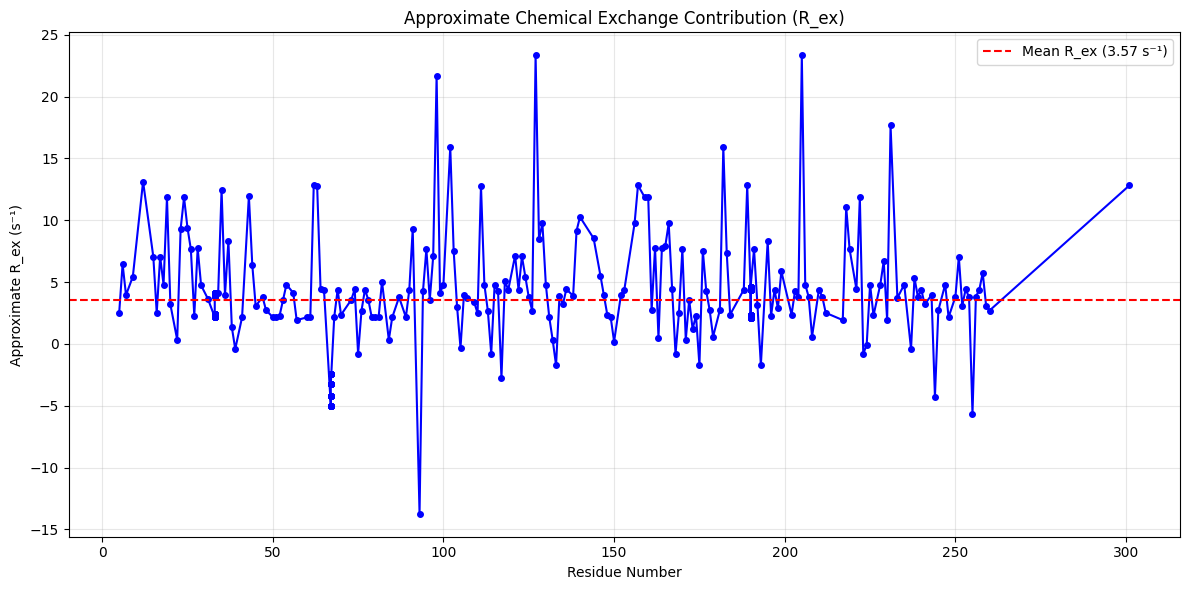

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from pathlib import Path

def parse_r1rho_file(file_path, field_name):
    """Parse a tab-separated R1rho file into a DataFrame, filtering for backbone amides."""
    df = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'label_repeat', 'R1rho_value'])
    df = df[df['label'] == df['label_repeat']].drop_duplicates(subset=['label'])
    df['R1rho_value'] = pd.to_numeric(df['R1rho_value'], errors='coerce')
    df['res_num'] = df['label'].str.extract(r'(\d+)').astype(float)
    df['field'] = field_name
    # Filter for backbone (N-HN or N-H)
    df = df[df['label'].str.contains('N-HN|N-H', na=False)]
    return df.dropna(subset=['res_num'])

# Define files and fields (based on uploaded data: 1k, 1.5k, 2k, 2.5k, 3k Hz)
files = {
    '1k': 'R1rho_ls_15N_on_1kexpfunfitresults.txt',
    '1.5k': 'R1rho_ls_15N_on_1.5kexpfunfitresults.txt',
    '2k': 'R1rho_ls_15N_on_2kexpfunfitresults.txt',
    '2.5k': 'R1rho_ls_15N_on_2.5kexpfunfitresults.txt',
    '3k': 'R1rho_ls_15N_on_3kexpfunfitresults.txt'
}

# Parse all files
dfs = {}
colors = ['maroon', 'red', 'purple', 'orange', 'green']  # Distinct colors per field
field_names = list(files.keys())
for i, (field, fpath) in enumerate(files.items()):
    if Path(fpath).exists():
        dfs[field] = parse_r1rho_file(fpath, field_names[i])
        print(f"{field_names[i]}: {len(dfs[field])} backbone points parsed")
    else:
        print(f"Warning: {fpath} not found")

# Merge on res_num (inner join for common residues)
common_res = set.intersection(*[set(df['res_num']) for df in dfs.values()])
print(f"\nCommon residues across all fields: {len(common_res)}")

merged_df = pd.DataFrame({'res_num': list(common_res)})
for field, df in dfs.items():
    merged_df = merged_df.merge(df[['res_num', 'R1rho_value']], on='res_num', how='left')
    merged_df.rename(columns={'R1rho_value': f'R1rho_{field}'}, inplace=True)

# Summary stats per field
print("\nSummary statistics per field (backbone only):")
for field in field_names:
    col = f'R1rho_{field}'
    if col in merged_df.columns:
        stats = merged_df[col].describe()
        print(f"\n{field}:")
        print(stats)

# Combined plot: Overlay R1rho vs. residue for all fields
plt.style.use('default')  # Clean style
fig, ax = plt.subplots(figsize=(14, 8))

subset = merged_df.sort_values('res_num')
for i, field in enumerate(field_names):
    if f'R1rho_{field}' in merged_df.columns:
        col = f'R1rho_{field}'
        ax.plot(subset['res_num'], subset[col], 'o-', linewidth=1.5, markersize=4,
                color=colors[i], label=f'{field} (mean {subset[col].mean():.2f} s⁻¹)')
        # Mean line
        ax.axhline(y=subset[col].mean(), color=colors[i], linestyle='--', alpha=0.7, linewidth=1)

ax.set_xlabel('Residue Number', fontsize=15)
ax.set_ylabel('¹⁵N R₁ρ (s⁻¹)', fontsize=15)
ax.set_title('Multi-Field ¹⁵N R₁ρ Relaxation Profiles (Backbone Amides)', fontsize=16)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=12)

# Style adjustments to mimic Mathematica (padding, frame, etc.)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.tight_layout(pad=1.5)
plt.savefig('multi_field_r1rho_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

# Save merged data
merged_df.to_csv('merged_r1rho_backbone.csv', index=False)
print("\nMerged data saved to 'merged_r1rho_backbone.csv'")
print("Overlay plot saved to 'multi_field_r1rho_overlay.png'")

# Optional: Compute simple R_ex approximation (e.g., R1rho(1k) - R1rho(3k) for exchange contribution)
if 'R1rho_1k' in merged_df.columns and 'R1rho_3k' in merged_df.columns:
    merged_df['R_ex_approx'] = merged_df['R1rho_1k'] - merged_df['R1rho_3k']
    print("\nSample R_ex approximation (R1rho_1k - R1rho_3k):")
    print(merged_df[['res_num', 'R_ex_approx']].sort_values('R_ex_approx', ascending=False).head(10))
    # Plot R_ex
    fig_ex, ax_ex = plt.subplots(figsize=(12, 6))
    subset_ex = merged_df.dropna(subset=['R_ex_approx']).sort_values('res_num')
    ax_ex.plot(subset_ex['res_num'], subset_ex['R_ex_approx'], 'o-', color='blue', markersize=4)
    ax_ex.axhline(y=subset_ex['R_ex_approx'].mean(), color='r', linestyle='--', label=f'Mean R_ex ({subset_ex["R_ex_approx"].mean():.2f} s⁻¹)')
    ax_ex.set_xlabel('Residue Number')
    ax_ex.set_ylabel('Approximate R_ex (s⁻¹)')
    ax_ex.set_title('Approximate Chemical Exchange Contribution (R_ex)')
    ax_ex.legend()
    ax_ex.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('r_ex_approx.png', dpi=300, bbox_inches='tight')
    plt.show()